In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print(cv2.__version__)

4.11.0


In [14]:
print("3.a)")

3.a)


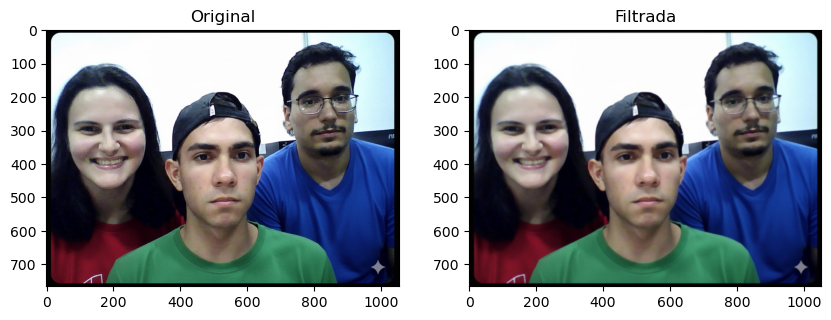

In [7]:
img_bgr = cv2.imread('foto-grupo.jpeg')
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Remoção de ruído (melhor prática)
blur = cv2.GaussianBlur(img, (5,5), 0)
median = cv2.medianBlur(blur, 5)

plt.figure(figsize=(10,5))
plt.subplot(121), plt.imshow(img), plt.title('Original')
plt.subplot(122), plt.imshow(median), plt.title('Filtrada')
plt.show()

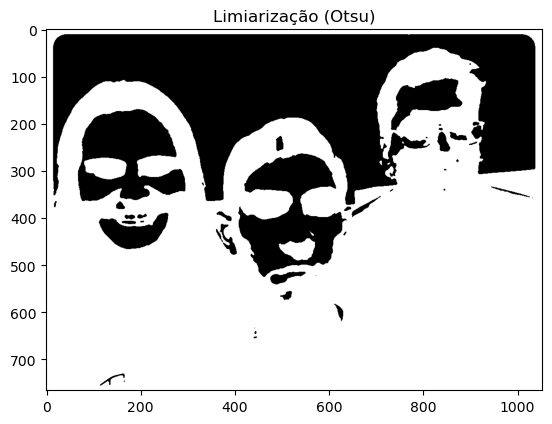

In [8]:
gray = cv2.cvtColor(median, cv2.COLOR_RGB2GRAY)

# Otsu
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

plt.imshow(thresh, cmap='gray')
plt.title('Limiarização (Otsu)')
plt.show()

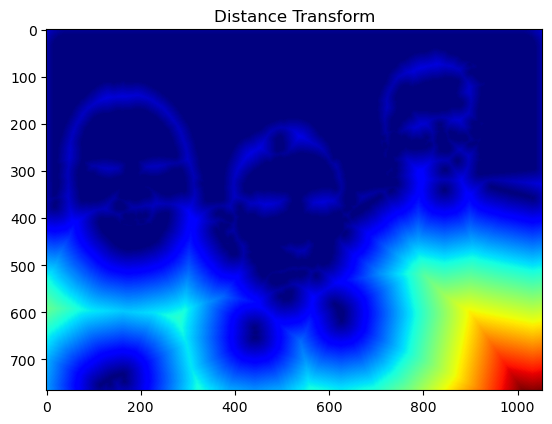

In [9]:
kernel = np.ones((3,3), np.uint8)

# Remove ruído
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Background
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Distance Transform
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

# Foreground
_, sure_fg = cv2.threshold(dist_transform, 0.7*dist_transform.max(), 255, 0)

sure_fg = np.uint8(sure_fg)

plt.imshow(dist_transform, cmap='jet')
plt.title('Distance Transform')
plt.show()

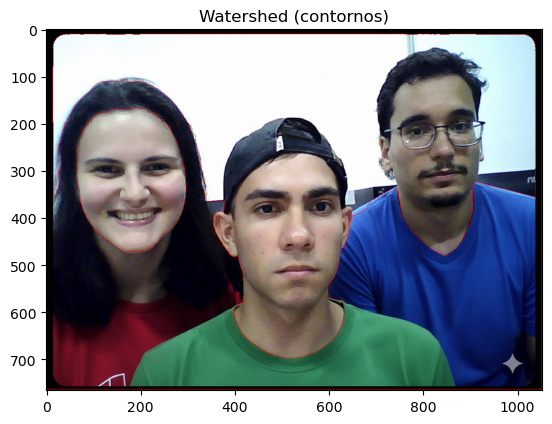

In [10]:
unknown = cv2.subtract(sure_bg, sure_fg)

# Rotulação
_, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1
markers[unknown == 255] = 0

# Watershed
markers = cv2.watershed(img_bgr, markers)

# Contornos
img_ws = img.copy()
img_ws[markers == -1] = [255, 0, 0]

plt.imshow(img_ws)
plt.title('Watershed (contornos)')
plt.show()

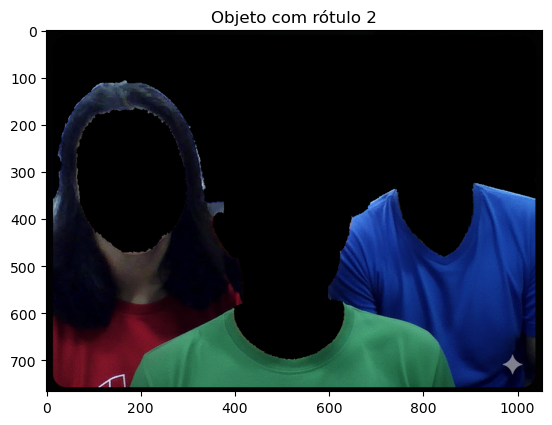

In [11]:
output_img = np.zeros_like(img)

# Exemplo: pegar label específico (ex: 2)
label = 2
output_img[markers == label] = img[markers == label]

plt.imshow(output_img)
plt.title(f'Objeto com rótulo {label}')
plt.show()

In [13]:
print("3.b)")

3.b)


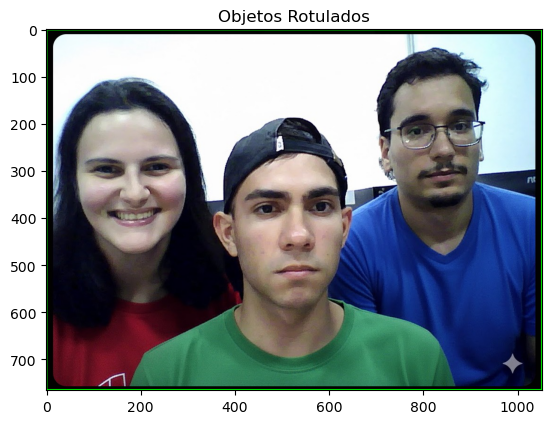

In [15]:
img_out = img.copy()

for label in np.unique(markers):
    if label <= 1:
        continue

    mask = np.uint8(markers == label)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        x,y,w,h = cv2.boundingRect(cnt)

        cv2.rectangle(img_out, (x,y), (x+w,y+h), (0,255,0), 2)
        cv2.putText(img_out, f'Obj {label}', (x,y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1)

plt.imshow(img_out)
plt.title('Objetos Rotulados')
plt.show()

In [13]:
print("3.c)")

3.b)


In [ ]:
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    blur = cv2.GaussianBlur(img, (5,5), 0)
    gray = cv2.cvtColor(blur, cv2.COLOR_RGB2GRAY)

    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, 2)
    sure_bg = cv2.dilate(opening, kernel, 3)

    dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist, 0.7*dist.max(), 255, 0)

    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)

    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    markers = cv2.watershed(frame, markers)

    frame[markers == -1] = [0,0,255]

    cv2.imshow('Watershed Webcam', frame)

    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

In [17]:
print("4.a)")

4.a)


In [ ]:
#TRECHO DO CODIGO DO PROJETO FINAL QUE USA SEGMENTACAO

kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(skin_mask, cv2.MORPH_OPEN, kernel, 2)

dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.5*dist.max(), 255, 0)

sure_fg = np.uint8(sure_fg)
_, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1
markers[opening == 0] = 0

markers = cv2.watershed(image, markers)